In [169]:
##!kaggle datasets list -s "harishkumardatalab/housing-price-prediction"

In [170]:
##from google.colab import drive
##drive.mount('/content/drive')

In [171]:
##%cd /content/drive/MyDrive/dataset

In [172]:
###amanbarthwal/imdb-movies-data
### 1. Dataset ko directly is folder me download karein
##!kaggle datasets download -d harishkumardatalab/housing-price-prediction
##
### 2. Download hui zip file ko unzip karein
##!unzip housing-price-prediction.zip
##
### 3. Faltu zip file ko delete karein (optional)
##!rm housing-price-prediction.zip

In [173]:
#Import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import scipy.stats as stats

#Pipeline implementation
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

#Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor

In [174]:
#Load dataset
df = pd.read_csv('/content/drive/MyDrive/dataset/Housing.csv')

In [175]:
#Check first 10 data
df.sample(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
283,4270000,4360,4,1,2,yes,no,no,no,no,0,no,furnished
314,4095000,4040,2,1,2,yes,no,no,no,no,1,no,semi-furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished
20,8750000,4320,3,1,2,yes,no,yes,yes,no,2,no,semi-furnished
205,4900000,6300,3,1,1,yes,no,no,no,yes,2,no,semi-furnished


In [176]:
#About dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [177]:
df.shape

(545, 13)

In [178]:
#Check null values
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [179]:
#Check duplicate values
df.duplicated().sum()

np.int64(0)

In [180]:
X = df.drop('price', axis=1)
y = df['price']

In [181]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

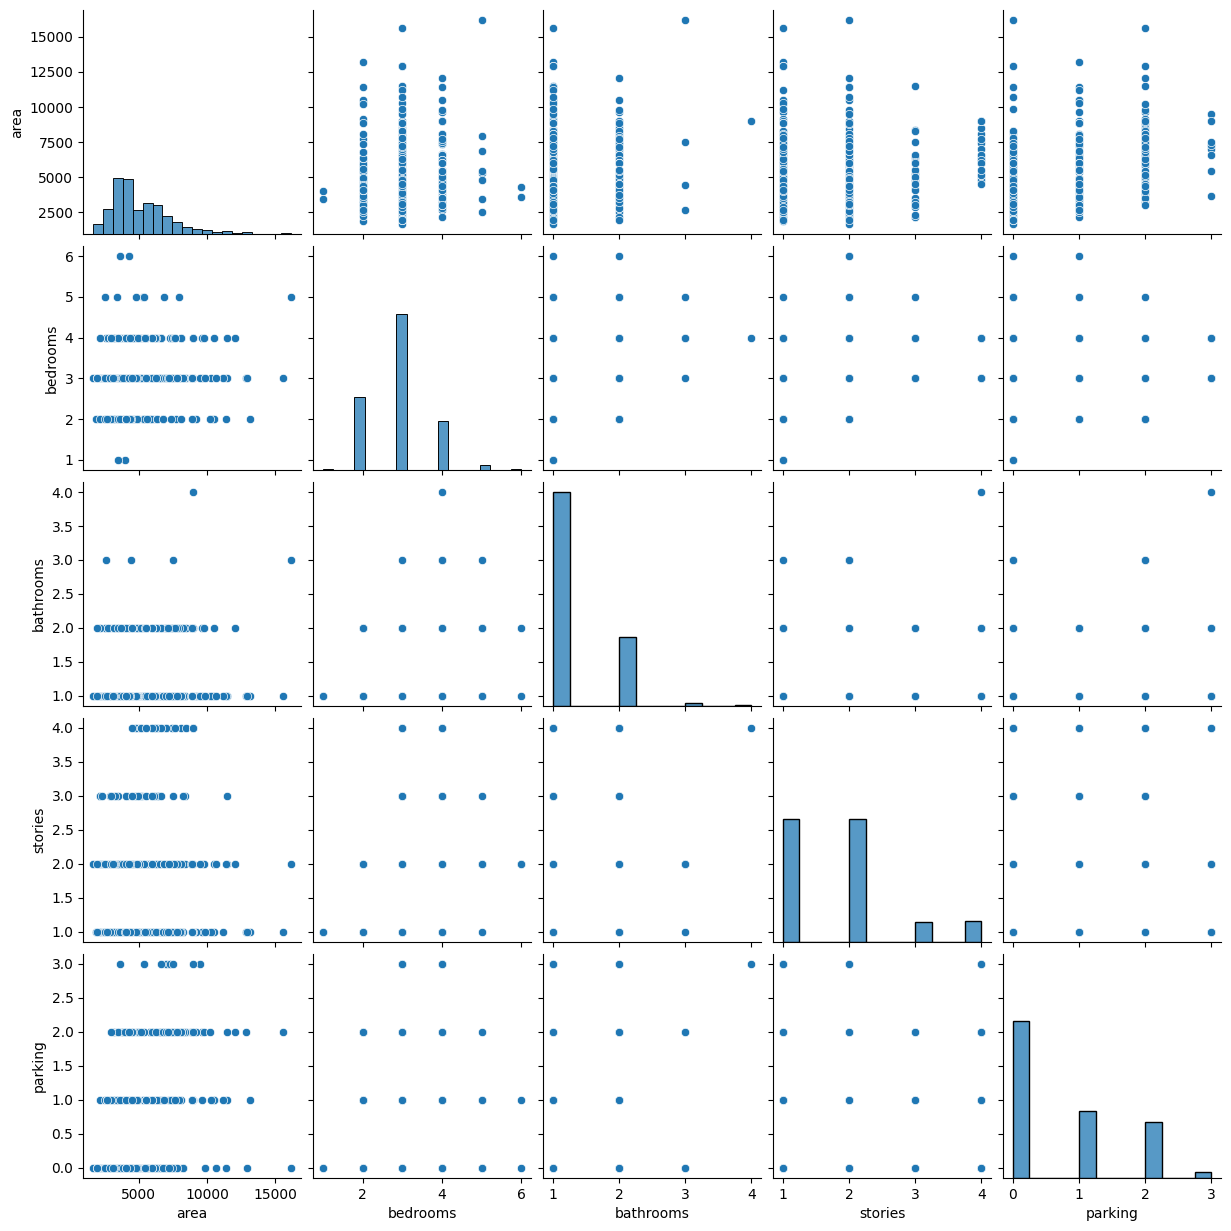

In [182]:
sns.pairplot(X_train)

In [183]:
numerical_cols = X_train.select_dtypes(include=np.number).columns
categorical_cols = X_train.select_dtypes(exclude=np.number).columns

print("Numerical Columns:")
print(numerical_cols)
print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

Categorical Columns:
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


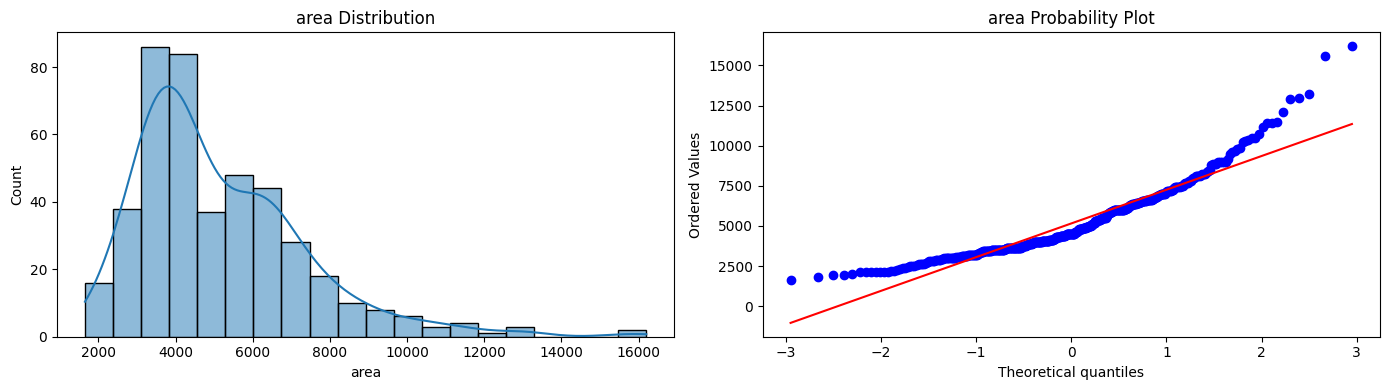

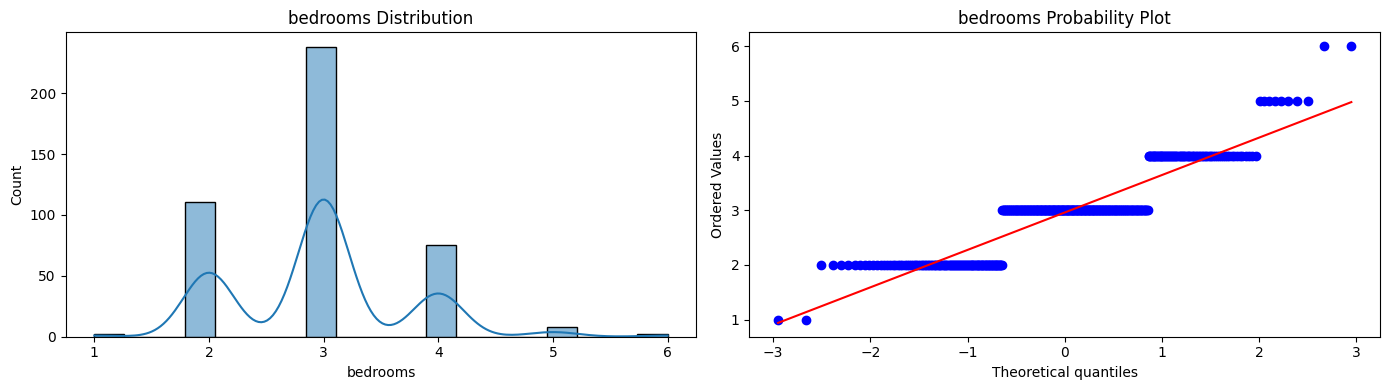

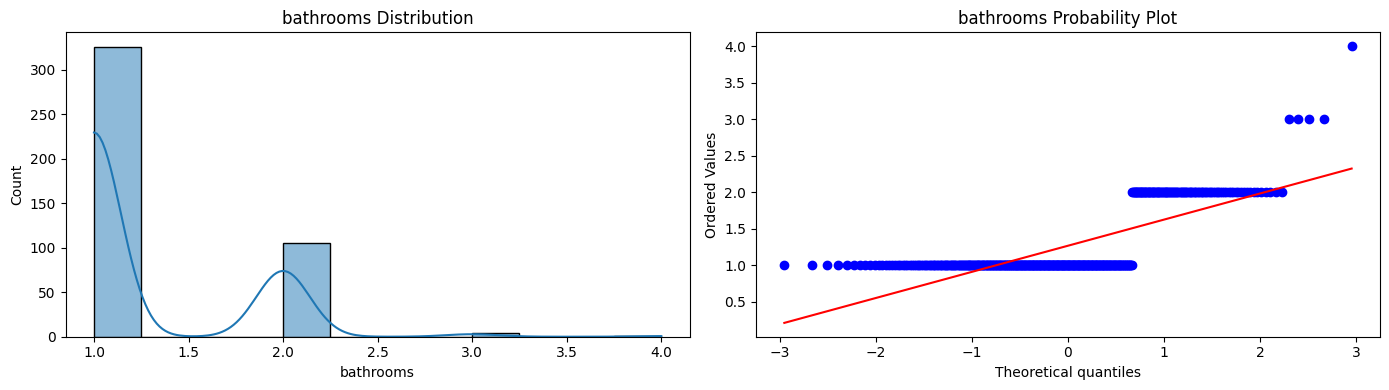

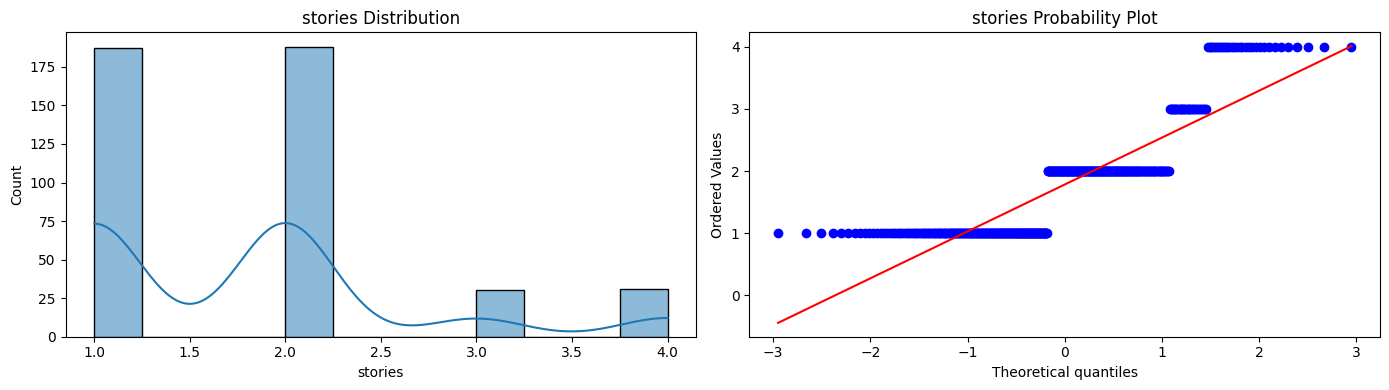

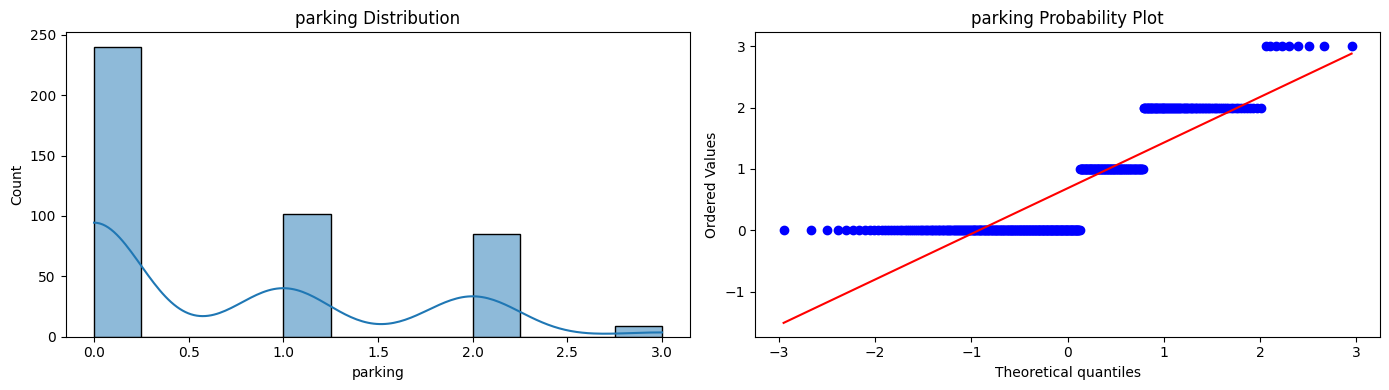

In [184]:
for col in numerical_cols:
    plt.figure(figsize=(14, 4))

    # 1. Distribution Plot (Left)
    plt.subplot(121)
    # Changed from displot to histplot to respect the subplot grid
    sns.histplot(data=X_train, x=col, kde=True)
    plt.title(f'{col} Distribution')

    # 2. QQ-Plot (Right)
    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(f'{col} Probability Plot')

    plt.tight_layout()  # Prevents overlapping text/labels
    plt.show()

In [185]:
X_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
46,6000,3,2,4,yes,no,no,no,yes,1,no,furnished
93,7200,3,2,1,yes,no,yes,no,yes,3,no,semi-furnished
335,3816,2,1,1,yes,no,yes,no,yes,2,no,furnished
412,2610,3,1,2,yes,no,yes,no,no,0,yes,unfurnished
471,3750,3,1,2,yes,no,no,no,no,0,no,unfurnished
...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,yes,no,no,no,yes,0,no,unfurnished
106,5450,4,2,1,yes,no,yes,no,yes,0,yes,semi-furnished
270,4500,3,2,3,yes,no,no,yes,no,1,no,furnished
435,4040,2,1,1,yes,no,no,no,no,0,no,unfurnished


In [207]:
# TF1: Numerical imputation
tf1 = ColumnTransformer(
    [('imputer1', SimpleImputer(), numerical_cols)],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

In [187]:
X_after_tf1 = tf1.fit_transform(X_train, y_train)

X_after_tf1.head()

,area,bedrooms,bathrooms,stories,parking,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
46,6000.0,3.0,2.0,4.0,1.0,yes,no,no,no,yes,no,furnished
93,7200.0,3.0,2.0,1.0,3.0,yes,no,yes,no,yes,no,semi-furnished
335,3816.0,2.0,1.0,1.0,2.0,yes,no,yes,no,yes,no,furnished
412,2610.0,3.0,1.0,2.0,0.0,yes,no,yes,no,no,yes,unfurnished
471,3750.0,3.0,1.0,2.0,0.0,yes,no,no,no,no,no,unfurnished


In [208]:
# TF2: Categorical imputation
tf2 = ColumnTransformer(
    [('imputer2', SimpleImputer(strategy='most_frequent'), categorical_cols)],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

In [189]:
X_after_tf2 = tf2.fit_transform(X_train, y_train)

X_after_tf2.head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus,area,bedrooms,bathrooms,stories,parking
46,yes,no,no,no,yes,no,furnished,6000,3,2,4,1
93,yes,no,yes,no,yes,no,semi-furnished,7200,3,2,1,3
335,yes,no,yes,no,yes,no,furnished,3816,2,1,1,2
412,yes,no,yes,no,no,yes,unfurnished,2610,3,1,2,0
471,yes,no,no,no,no,no,unfurnished,3750,3,1,2,0


In [209]:
# TF3: One-hot encoding
tf3 = ColumnTransformer(
    [('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
     ['mainroad', 'guestroom', 'basement',
      'hotwaterheating', 'airconditioning', 'prefarea'])],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

In [191]:
X_after_tf3 = tf3.fit_transform(X_train, y_train)

X_after_tf3.head()

,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,area,bedrooms,bathrooms,stories,parking,furnishingstatus
46,1.0,0.0,0.0,0.0,1.0,0.0,6000,3,2,4,1,furnished
93,1.0,0.0,1.0,0.0,1.0,0.0,7200,3,2,1,3,semi-furnished
335,1.0,0.0,1.0,0.0,1.0,0.0,3816,2,1,1,2,furnished
412,1.0,0.0,1.0,0.0,0.0,1.0,2610,3,1,2,0,unfurnished
471,1.0,0.0,0.0,0.0,0.0,0.0,3750,3,1,2,0,unfurnished


In [192]:
#df['furnishingstatus'].unique().tolist()

In [193]:
# TF4: Scaling
tf4 = ColumnTransformer(
    [('scaler', StandardScaler(), ['area'])],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

In [194]:
X_after_tf4 = tf4.fit_transform(X_train, y_train)

X_after_tf4.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
46,0.384168,3,2,4,yes,no,no,no,yes,1,no,furnished
93,0.929181,3,2,1,yes,no,yes,no,yes,3,no,semi-furnished
335,-0.607755,2,1,1,yes,no,yes,no,yes,2,no,furnished
412,-1.155492,3,1,2,yes,no,yes,no,no,0,yes,unfurnished
471,-0.637730,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [210]:
# TF5: Ordinal Encoding
tf5 = ColumnTransformer(
    [('encoder2', OrdinalEncoder(), ['furnishingstatus'])],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

In [196]:
X_after_tf5 = tf5.fit_transform(X_train, y_train)

X_after_tf5.head()

,furnishingstatus,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
46,0.0,6000,3,2,4,yes,no,no,no,yes,1,no
93,1.0,7200,3,2,1,yes,no,yes,no,yes,3,no
335,0.0,3816,2,1,1,yes,no,yes,no,yes,2,no
412,2.0,2610,3,1,2,yes,no,yes,no,no,0,yes
471,2.0,3750,3,1,2,yes,no,no,no,no,0,no


In [218]:
#Machine Learning Model
tf6 = GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=2,
        min_samples_split=5,
        min_samples_leaf=3,
        random_state=42
)

In [219]:
pipe = Pipeline(
    [
        ('tf1', tf1),
        ('tf2', tf2),
        ('tf3', tf3),
        #('tf4', tf4),
        ('tf5', tf5),
        ('tf6', tf6)
    ]
)

In [220]:
pipe

Pipeline(steps=[('tf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer1', SimpleImputer(),
                                                  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('tf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer2',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  Index(['mainroad',...
                                                   'airconditioning',
                                                   'prefarea'])],
                                   verbose_feature_names_out=False)),
                ('tf5',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoder2', OrdinalEncoder(),
                                                  ['furnishingstatus'])],
                                   verbose_feature_names_out=False)),
                ('tf6',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=2,
                                           min_samples_leaf=3,
                                           min_samples_split=5,
                                           n_estimators=500,
                                           random_state=42))])

In [221]:
X_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
46,6000,3,2,4,yes,no,no,no,yes,1,no,furnished
93,7200,3,2,1,yes,no,yes,no,yes,3,no,semi-furnished
335,3816,2,1,1,yes,no,yes,no,yes,2,no,furnished
412,2610,3,1,2,yes,no,yes,no,no,0,yes,unfurnished
471,3750,3,1,2,yes,no,no,no,no,0,no,unfurnished
...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,yes,no,no,no,yes,0,no,unfurnished
106,5450,4,2,1,yes,no,yes,no,yes,0,yes,semi-furnished
270,4500,3,2,3,yes,no,no,yes,no,1,no,furnished
435,4040,2,1,1,yes,no,no,no,no,0,no,unfurnished


In [222]:
pipe.set_output(transform='pandas')

pipe.fit(X_train, y_train)

#y_pred

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('tf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer1', SimpleImputer(),
                                                  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('tf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer2',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  Index(['mainroad',...
                                                   'airconditioning',
                                                   'prefarea'])],
                                   verbose_feature_names_out=False)),
                ('tf5',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoder2', OrdinalEncoder(),
                                                  ['furnishingstatus'])],
                                   verbose_feature_names_out=False)),
                ('tf6',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=2,
                                           min_samples_leaf=3,
                                           min_samples_split=5,
                                           n_estimators=500,
                                           random_state=42))])

In [223]:
pipe.score(X_test, y_test)

0.656239903898066

          MODEL                         Accuracy
### Linear Regression model         - 0.6494754192267791
### Decision Tree model             - 0.4443624157070456
### RandomForestRegressor model     - 0.6089029323678894
### GradientBoostingRegressor model - 0.6634517846928968
### AdaBoostRegressor model         - 0.5325276520442883

In [203]:
y_pred = pipe.predict(X_test)

y_pred

array([ 4745426.56920084,  7272841.90043154,  3582209.53780996,
        4630148.63881479,  3540073.40622954,  4173609.83988324,
        5657315.88818961,  5818118.18213851,  3106147.25329718,
        2986901.2738421 , 10990118.95777303,  2931611.50533819,
        3219017.31119137,  3561897.09453504,  3601259.70807577,
        4892327.6073863 ,  3020315.20022399,  5573342.47203053,
        4439158.02452642,  4300408.01517069,  5309127.67900363,
        5987642.0028446 ,  2909280.33159318,  4438487.05233665,
        5151188.9820652 ,  6682210.9051807 ,  3531236.17258828,
        4655282.71807401,  7317147.703892  ,  3422070.2079776 ,
        5511350.5231655 ,  3362420.66550379,  6993712.76999421,
        4585406.85159465,  3562005.39355615,  5891097.29987733,
        4648276.02633553,  3828149.7045475 ,  2991085.43529867,
        4188185.0981333 ,  4866117.36707721,  3208557.04261812,
        7272841.90043154,  4305403.87563586,  4251967.29671244,
        4148321.29589369,  7204812.72887

In [224]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")

Mean Squared Error: 1855581067769.5527
Mean Absolute Error: 1000076.4125020404
R-squared: 0.6328904382907865


In [225]:
print("Training R2 Score:",
      pipe.score(X_train, y_train))

print("Testing R2 Score:",
      r2_score(y_test, y_pred))

Training R2 Score: 0.8330040562498411
Testing R2 Score: 0.6328904382907865


In [226]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    pipe,
    X,
    y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("CV Scores:", scores)
print("Mean CV R2:", scores.mean())

CV Scores: [ -2.504892    -7.43453894 -15.25891033 -16.79141217  -7.32309578]
Mean CV R2: -9.86256984382518
